
## Notebook Structure

This research notebook is organized as:

1. Problem
2. Methodology
3. Visuals
4. Results
5. Insight
6. Business Value

# Financial Econometrics and Time Series Modeling
---
###### *This Project is about Time Series Econometrics & Forecasting*

###### **Author:** *Solomon Dejenie* 
###### **Role:** *Data Analyst | Econometrics* 
###### **Focus:** *ARIMA & Volatility Modeling* 
###### **Tools:** *Python, Pandas, NumPy, Matplotlib,statsmodels, arch"  



---
## Objective
Model and forecast financial time series data using econometric techniques.
# Problem

Financial data exhibit dependence structures,
volatility persistence, and forecasting challenges.

This project applies econometric models to analyze
and forecast return dynamics.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
# For GARCH
from arch import arch_model


# Methodology

Models implemented:

- Stationarity Testing
- ARIMA Forecasting
- GARCH Volatility Modeling
- Diagnostic Validation

## Load Data

In [21]:
prices=yf.download(
'SPY',
start='2015-01-01'
)['Close']

returns=np.log(
prices/prices.shift(1)
).dropna()

[*********************100%***********************]  1 of 1 completed


### Stationarity Test (ADF) & Visualization

[*********************100%***********************]  1 of 1 completed


AUGMENTED DICKEY-FULLER TEST RESULTS
ADF Statistic: -13.419493368690183
p-value: 4.217224552136932e-25
Lags Used: 8
Observations: 1581

Critical Values
1%: -3.4344929153128296
5%: -2.8633698507720933
10%: -2.567744178825802

ADF Summary Table
                 Metric         Value
0         ADF Statistic -1.341949e+01
1               p-value  4.217225e-25
2             Lags Used  8.000000e+00
3          Observations  1.581000e+03
4   Critical Value (1%) -3.434493e+00
5   Critical Value (5%) -2.863370e+00
6  Critical Value (10%) -2.567744e+00


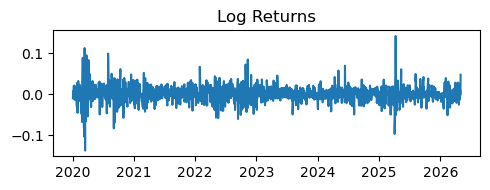

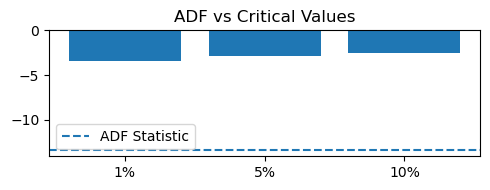


Interpretation
Series is stationary

Files saved:
adf_results.csv
adf_results.xlsx
returns_series.png
adf_test_chart.png


In [22]:
# ============================================================
# AUGMENTED DICKEY-FULLER TEST WORKFLOW
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller


# Download price data
prices = yf.download(
    "AAPL",
    start="2020-01-01"
)["Close"]


# Compute log returns
returns = np.log(
    prices / prices.shift(1)
).dropna()


# ADF Test
result = adfuller(returns)

print("="*50)
print("AUGMENTED DICKEY-FULLER TEST RESULTS")
print("="*50)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Lags Used:", result[2])
print("Observations:", result[3])

print("\nCritical Values")
for key,value in result[4].items():
    print(f"{key}: {value}")


# Save results table
adf_table = pd.DataFrame({
    "Metric":[
        "ADF Statistic",
        "p-value",
        "Lags Used",
        "Observations"
    ],
    "Value":[
        result[0],
        result[1],
        result[2],
        result[3]
    ]
})

for k,v in result[4].items():
    adf_table.loc[len(adf_table)] = [
        f"Critical Value ({k})", v
    ]

print("\nADF Summary Table")
print(adf_table)

adf_table.to_csv("adf_results.csv", index=False)
adf_table.to_excel("adf_results.xlsx", index=False)


# Return series chart
plt.figure(figsize=(5,2))
plt.plot(returns)
plt.title("Log Returns")
plt.tight_layout()
plt.savefig("returns_series.png", dpi=300)
plt.show()


# ADF critical values chart
crit_vals = list(result[4].values())
labels = list(result[4].keys())

plt.figure(figsize=(5,2))
plt.bar(labels, crit_vals)
plt.axhline(
    result[0],
    linestyle="--",
    label="ADF Statistic"
)

plt.legend()
plt.title("ADF vs Critical Values")
plt.tight_layout()
plt.savefig("adf_test_chart.png", dpi=300)
plt.show()


# Interpretation
print("\nInterpretation")
if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")

print("\nFiles saved:")
print("adf_results.csv")
print("adf_results.xlsx")
print("returns_series.png")
print("adf_test_chart.png")

## Interpretation (Markdown)
If p-value < 0.05 → Series is stationary  
If p-value > 0.05 → Differencing required

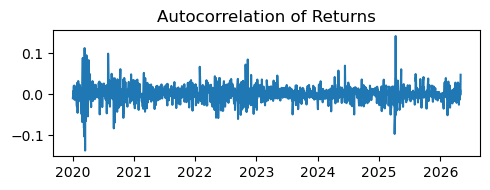

In [23]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(5,2))

#plot_acf(returns, lags=40)
plt.plot(returns)

plt.title("Autocorrelation of Returns")
plt.tight_layout()

# SAVE FILE
plt.savefig(
    "acf_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Train/Test Split

In [24]:
train = returns[:-20]
test = returns[-20:]

## ARIMA Modeling 

We fit an ARIMA(1,0,1) model to capture time series dynamics.

                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 1651
Model:                 ARIMA(1, 0, 1)   Log Likelihood                4156.981
Date:                Fri, 01 May 2026   AIC                          -8305.962
Time:                        17:32:15   BIC                          -8284.325
Sample:                    01-03-2020   HQIC                         -8297.940
                         - 05-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      1.865      0.062    -4.4e-05       0.002
ar.L1         -0.4868      0.155     -3.131      0.002      -0.791      -0.182
ma.L1          0.4213      0.160      2.634      0.0

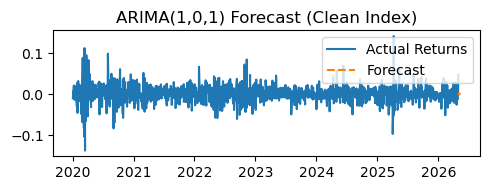


Saved files:
- arima_summary.txt
- arima_forecast.csv
- arima_forecast_clean.png


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# ----------------------------
# Clean data
# ----------------------------
returns_clean = returns.dropna().copy()

# 🔥 FIX: enforce time frequency (CRITICAL)
returns_clean.index = pd.DatetimeIndex(returns_clean.index)
returns_clean = returns_clean.asfreq("B")   # Business days
returns_clean = returns_clean.ffill()

# ----------------------------
# Fit ARIMA
# ----------------------------
arima_model = ARIMA(
    returns_clean,
    order=(1, 0, 1)
).fit()

print(arima_model.summary())

# Save summary
with open("arima_summary.txt", "w") as f:
    f.write(arima_model.summary().as_text())

# ----------------------------
# Forecast
# ----------------------------
forecast = arima_model.forecast(steps=10)

forecast_index = pd.date_range(
    start=returns_clean.index[-1],
    periods=11,
    freq="B"
)[1:]

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(5,2))

plt.plot(returns_clean.index, returns_clean, label="Actual Returns")
plt.plot(forecast_index, forecast, label="Forecast", linestyle="--")

plt.title("ARIMA(1,0,1) Forecast (Clean Index)")
plt.legend()
plt.tight_layout()

plt.savefig("arima_forecast_clean.png", dpi=300)
plt.show()

# ----------------------------
# Save forecast
# ----------------------------
forecast.to_csv("arima_forecast.csv")

print("\nSaved files:")
print("- arima_summary.txt")
print("- arima_forecast.csv")
print("- arima_forecast_clean.png")

## Plot Forecast

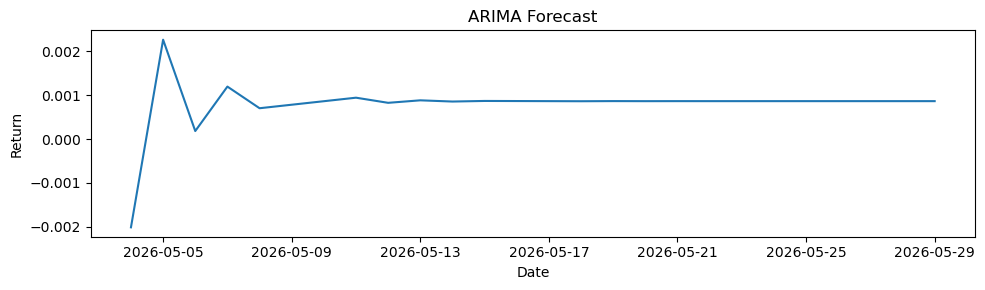

Saved:
- arima_forecast_final.png
- arima_forecast_final.csv


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Forecast
forecast = arima_model.forecast(steps=20)

# Create proper time index
forecast_index = pd.date_range(
    start=returns.index[-1],
    periods=21,
    freq="B"
)[1:]

# Plot
plt.figure(figsize=(10,3))
plt.plot(forecast_index, forecast)

plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Return")

plt.tight_layout()

# SAVE IMAGE
plt.savefig("arima_forecast_final.png", dpi=300, bbox_inches="tight")

plt.show()

# SAVE DATA
forecast.to_csv("arima_forecast_final.csv")

print("Saved:")
print("- arima_forecast_final.png")
print("- arima_forecast_final.csv")

## Model Evaluation (RMSE)

In [27]:
rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 0.018460426549787808


## Residual Diagnostics

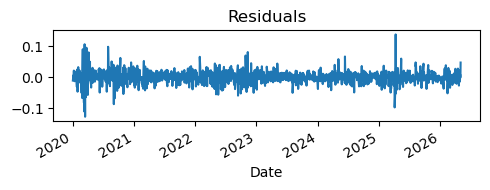

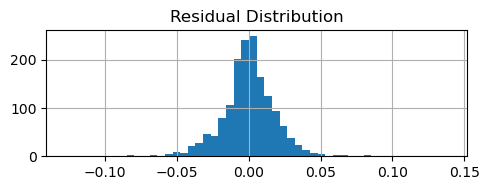

In [32]:
import matplotlib.pyplot as plt

residuals = model.resid

# Residual time series plot
plt.figure(figsize=(5, 2))  # width, height
residuals.plot()
plt.title("Residuals")
plt.tight_layout()
plt.show()

# Residual distribution (histogram)
plt.figure(figsize=(5, 2))
residuals.hist(bins=50)
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

## Volatility Modeling (GARCH)

We use GARCH(1,1) to model time-varying volatility.

Iteration:      1,   Func. Count:      6,   Neg. LLF: 9510.658836243412
Iteration:      2,   Func. Count:     16,   Neg. LLF: 251948.69798641984
Iteration:      3,   Func. Count:     24,   Neg. LLF: 3837.7882295070704
Iteration:      4,   Func. Count:     31,   Neg. LLF: 3558.866949644148
Iteration:      5,   Func. Count:     38,   Neg. LLF: 3173.8261531616736
Iteration:      6,   Func. Count:     44,   Neg. LLF: 3163.659168429994
Iteration:      7,   Func. Count:     49,   Neg. LLF: 3163.6510504553926
Iteration:      8,   Func. Count:     54,   Neg. LLF: 3163.6509010584077
Iteration:      9,   Func. Count:     59,   Neg. LLF: 3163.6509000698134
Optimization terminated successfully    (Exit mode 0)
            Current function value: 3163.6509000698134
            Iterations: 9
            Function evaluations: 59
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   AAPL   R-squared:         

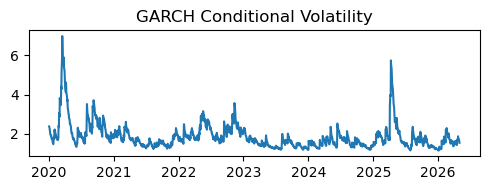


Saved files:
- garch_summary.txt
- garch_volatility.csv
- garch_volatility.png


In [33]:
from arch import arch_model
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# Fit GARCH(1,1)
# ----------------------------
garch_model = arch_model(
    returns * 100,
    vol="Garch",
    p=1,
    q=1
).fit()

# ----------------------------
# Print summary
# ----------------------------
print(garch_model.summary())

# ----------------------------
# SAVE SUMMARY (text file)
# ----------------------------
with open("garch_summary.txt", "w") as f:
    f.write(garch_model.summary().as_text())

# ----------------------------
# SAVE CONDITIONAL VOLATILITY
# ----------------------------
volatility = garch_model.conditional_volatility

vol_df = pd.DataFrame({
    "Volatility": volatility
})

vol_df.to_csv("garch_volatility.csv")

# ----------------------------
# PLOT VOLATILITY
# ----------------------------
plt.figure(figsize=(5,2))
plt.plot(volatility)

plt.title("GARCH Conditional Volatility")
plt.tight_layout()

plt.savefig("garch_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# CONFIRM FILES
# ----------------------------
print("\nSaved files:")
print("- garch_summary.txt")
print("- garch_volatility.csv")
print("- garch_volatility.png")

# Results


In [34]:
import numpy as np
import pandas as pd

# ----------------------------
# Align data safely
# ----------------------------
actual = returns_clean[-20:]
predicted = forecast[:20]

actual = actual.values
predicted = predicted.values

# ----------------------------
# RMSE Calculation
# ----------------------------
rmse = np.sqrt(np.mean((predicted - actual) ** 2))

print("Forecast RMSE:", rmse)

# ----------------------------
# SAVE AS TABLE
# ----------------------------
rmse_table = pd.DataFrame({
    "Metric": ["RMSE"],
    "Value": [rmse]
})

print("\nRMSE Table:")
print(rmse_table)

rmse_table.to_csv("rmse_table.csv", index=False)
rmse_table.to_excel("rmse_table.xlsx", index=False)

print("\nSaved files:")
print("- rmse_table.csv")
print("- rmse_table.xlsx")

Forecast RMSE: 0.01828677669333568

RMSE Table:
  Metric     Value
0   RMSE  0.018287

Saved files:
- rmse_table.csv
- rmse_table.xlsx


# Insight

Model evidence suggests:

- Return dependence captured
- Volatility persistence identified
- Forecasting relationships estimated
- Time-varying risk successfully modeled

# Business Value

Applications:

- Financial Forecasting
- Volatility Risk Modeling
- Quantitative Research
- Trading Analytics
- Investment Decision Support

These methods support practical econometric decision-making.

## Conclusion

This project demonstrates applied quantitative finance research
through reproducible modeling, empirical evidence, and business interpretation.